<a href="https://colab.research.google.com/github/Piyush22105061/saas_churn_retention_analysis/blob/main/notebooks/03a_cohort_retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q sqlalchemy psycopg2-binary pandas openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 37.7 MB/s eta 0:00:00


In [2]:
from sqlalchemy import create_engine
import pandas as pd

HOST = "aws-0-ap-south-1.pooler.supabase.com"
PORT = 5432
DATABASE = "postgres"

USERNAME = "saas_ro_user.imnzftquwjuxcwpeufwp"
PASSWORD = "saas-read-only"      # Replace with your actual password

SCHEMA = "saas"

engine = create_engine(
    f"postgresql+psycopg2://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

print("Connected!")

Connected!


In [3]:
subscriptions = pd.read_sql(
    "SELECT * FROM saas.subscriptions",
    engine
)

accounts = pd.read_sql(
    "SELECT * FROM saas.accounts",
    engine
)

In [4]:
accounts.head()

,account_id,name,account_type,industry,employee_count,country,signup_date,acquisition_channel
0,100874,NetPulse,self_serve,None,1,United States,2022-12-14 00:00:00+00:00,organic
1,100002,DigiWorks,self_serve,None,1,United States,2024-11-04 00:00:00+00:00,google_ads
2,100014,SynapseAI,self_serve,None,1,United States,2025-06-16 00:00:00+00:00,organic
3,100042,PivotPoint,self_serve,None,1,United States,2026-03-19 00:00:00+00:00,organic
4,100073,TechVentures,self_serve,None,1,United States,2025-04-26 00:00:00+00:00,direct


In [5]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   account_id           1250 non-null   int64              
 1   name                 1250 non-null   object             
 2   account_type         1250 non-null   object             
 3   industry             250 non-null    object             
 4   employee_count       1250 non-null   int64              
 5   country              1250 non-null   object             
 6   signup_date          1250 non-null   datetime64[ns, UTC]
 7   acquisition_channel  1102 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(2), object(5)
memory usage: 78.3+ KB


In [6]:
subscriptions.status.value_counts()

,count
status,
active,885
churned,557
trialing,292
past_due,195
paused,184


In [7]:
subscriptions.plan.value_counts()

,count
plan,
pro,348
starter,347
professional,294
enterprise,287
Enterprise,285
Pro,282
free,270


In [8]:
subscriptions["plan"] = (
    subscriptions["plan"]
    .str.lower()
    .replace({
        "professional":"pro",
        'pro':'pro'
    })
)

In [9]:
accounts["cohort"] = (
    accounts["signup_date"]
        .dt.to_period("M")
)

/tmp/ipykernel_1433/2332603755.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


In [10]:
cohort_size = (
    accounts
    .groupby("cohort")["account_id"]
    .nunique()
    .reset_index(name="cohort_size")
)

cohort_size

,cohort,cohort_size
0,2022-01,15
1,2022-02,20
2,2022-03,23
3,2022-04,16
4,2022-05,20
5,2022-06,17
6,2022-07,16
7,2022-08,23
8,2022-09,28
9,2022-10,19


In [11]:
subscriptions = subscriptions.merge(
    accounts[["account_id", "cohort"]],
    on="account_id",
    how="left"
)

subscriptions.head()

,subscription_id,user_id,plan,start_date,end_date,mrr,status,cancelled_at,cancellation_reason,account_id,seat_count,plan_id,cohort
0,822,625.0,pro,2024-04-07,NaT,63.96,paused,NaT,None,100625,1,NaN,2022-08
1,69,438.0,pro,2023-02-15,NaT,84.05,past_due,NaT,None,100438,1,NaN,2022-09
2,94,679.0,pro,2025-08-16,NaT,68.15,past_due,NaT,None,100679,1,NaN,2024-12
3,122,947.0,pro,2023-11-14,NaT,163.96,paused,NaT,None,100947,1,NaN,2022-06
4,176,769.0,enterprise,2026-03-23,NaT,532.99,past_due,NaT,None,100769,1,NaN,2025-07


In [15]:
def get_active_accounts(subscriptions, snapshot_date):

    active = subscriptions[
        (subscriptions["start_date"] <= snapshot_date)
        & (subscriptions['status'] == 'active') &
        (
            subscriptions["end_date"].isna()
            |
            (subscriptions["end_date"] > snapshot_date)
        )
    ]

    return (
        active["account_id"]
        .drop_duplicates()
    )

In [16]:
latest_snapshot = subscriptions["start_date"].max().to_period("M")

earliest_cohort = accounts["cohort"].min()

max_months = (
    (latest_snapshot.year - earliest_cohort.year) * 12
    +
    (latest_snapshot.month - earliest_cohort.month)
)

In [17]:
from pandas.tseries.offsets import DateOffset

retention = []

for cohort in sorted(accounts["cohort"].dropna().unique()):

    cohort_start = cohort.to_timestamp()

    cohort_accounts = accounts.loc[
        accounts["cohort"] == cohort,
        "account_id"
    ]

    cohort_size = len(cohort_accounts)

    for month in range(max_months + 1):

        snapshot = cohort_start + pd.DateOffset(months=month)

        active_accounts = get_active_accounts(
            subscriptions,
            snapshot
        )

        retained = (
            cohort_accounts
            .isin(active_accounts)
            .sum()
        )

        retention.append({

            "cohort": str(cohort),

            "month_number": month,

            "snapshot": snapshot,

            "retained_accounts": retained,

            "cohort_size": cohort_size,

            "retention_rate": retained / cohort_size

        })

In [18]:
retention = pd.DataFrame(retention)

In [19]:
import numpy as np
today = pd.Timestamp.today().normalize()

retention.loc[
    retention["snapshot"] > today,
    "retention_rate"
] = np.nan

In [20]:
cohort_matrix = retention.pivot(

    index="cohort",

    columns="month_number",

    values="retention_rate"

)

In [21]:
cohort_matrix[0] = 1.0

In [27]:
cohort_matrix

month_number,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
cohort,,,,,,,,,,,,,,,,,,,,,
2022-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.133333,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.000000,0.000000,0.00
2022-02,1.0,0.000000,0.000000,0.000000,0.050000,0.050000,0.050000,0.100000,0.200000,0.200000,...,0.400000,0.400000,0.400000,0.400000,0.400000,0.350000,0.300000,0.300000,0.350000,0.35
2022-03,1.0,0.000000,0.000000,0.043478,0.086957,0.130435,0.130435,0.130435,0.130435,0.130435,...,0.260870,0.260870,0.260870,0.260870,0.217391,0.217391,0.217391,0.173913,0.173913,NaN
2022-04,1.0,0.000000,0.000000,0.000000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,...,0.187500,0.187500,0.250000,0.250000,0.187500,0.187500,0.187500,0.187500,NaN,NaN
2022-05,1.0,0.000000,0.150000,0.150000,0.150000,0.150000,0.200000,0.200000,0.250000,0.200000,...,0.250000,0.200000,0.200000,0.200000,0.150000,0.150000,0.100000,NaN,NaN,NaN
2022-06,1.0,0.000000,0.000000,0.000000,0.058824,0.058824,0.058824,0.058824,0.058824,0.058824,...,0.176471,0.176471,0.176471,0.176471,0.176471,0.176471,NaN,NaN,NaN,NaN
2022-07,1.0,0.000000,0.062500,0.062500,0.062500,0.062500,0.062500,0.125000,0.125000,0.187500,...,0.187500,0.187500,0.250000,0.250000,0.187500,NaN,NaN,NaN,NaN,NaN
2022-08,1.0,0.000000,0.000000,0.086957,0.086957,0.086957,0.086957,0.086957,0.086957,0.086957,...,0.130435,0.130435,0.130435,0.130435,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,1.0,0.000000,0.000000,0.000000,0.035714,0.035714,0.035714,0.035714,0.035714,0.107143,...,0.035714,0.035714,0.035714,NaN,NaN,NaN,NaN,NaN,NaN,NaN


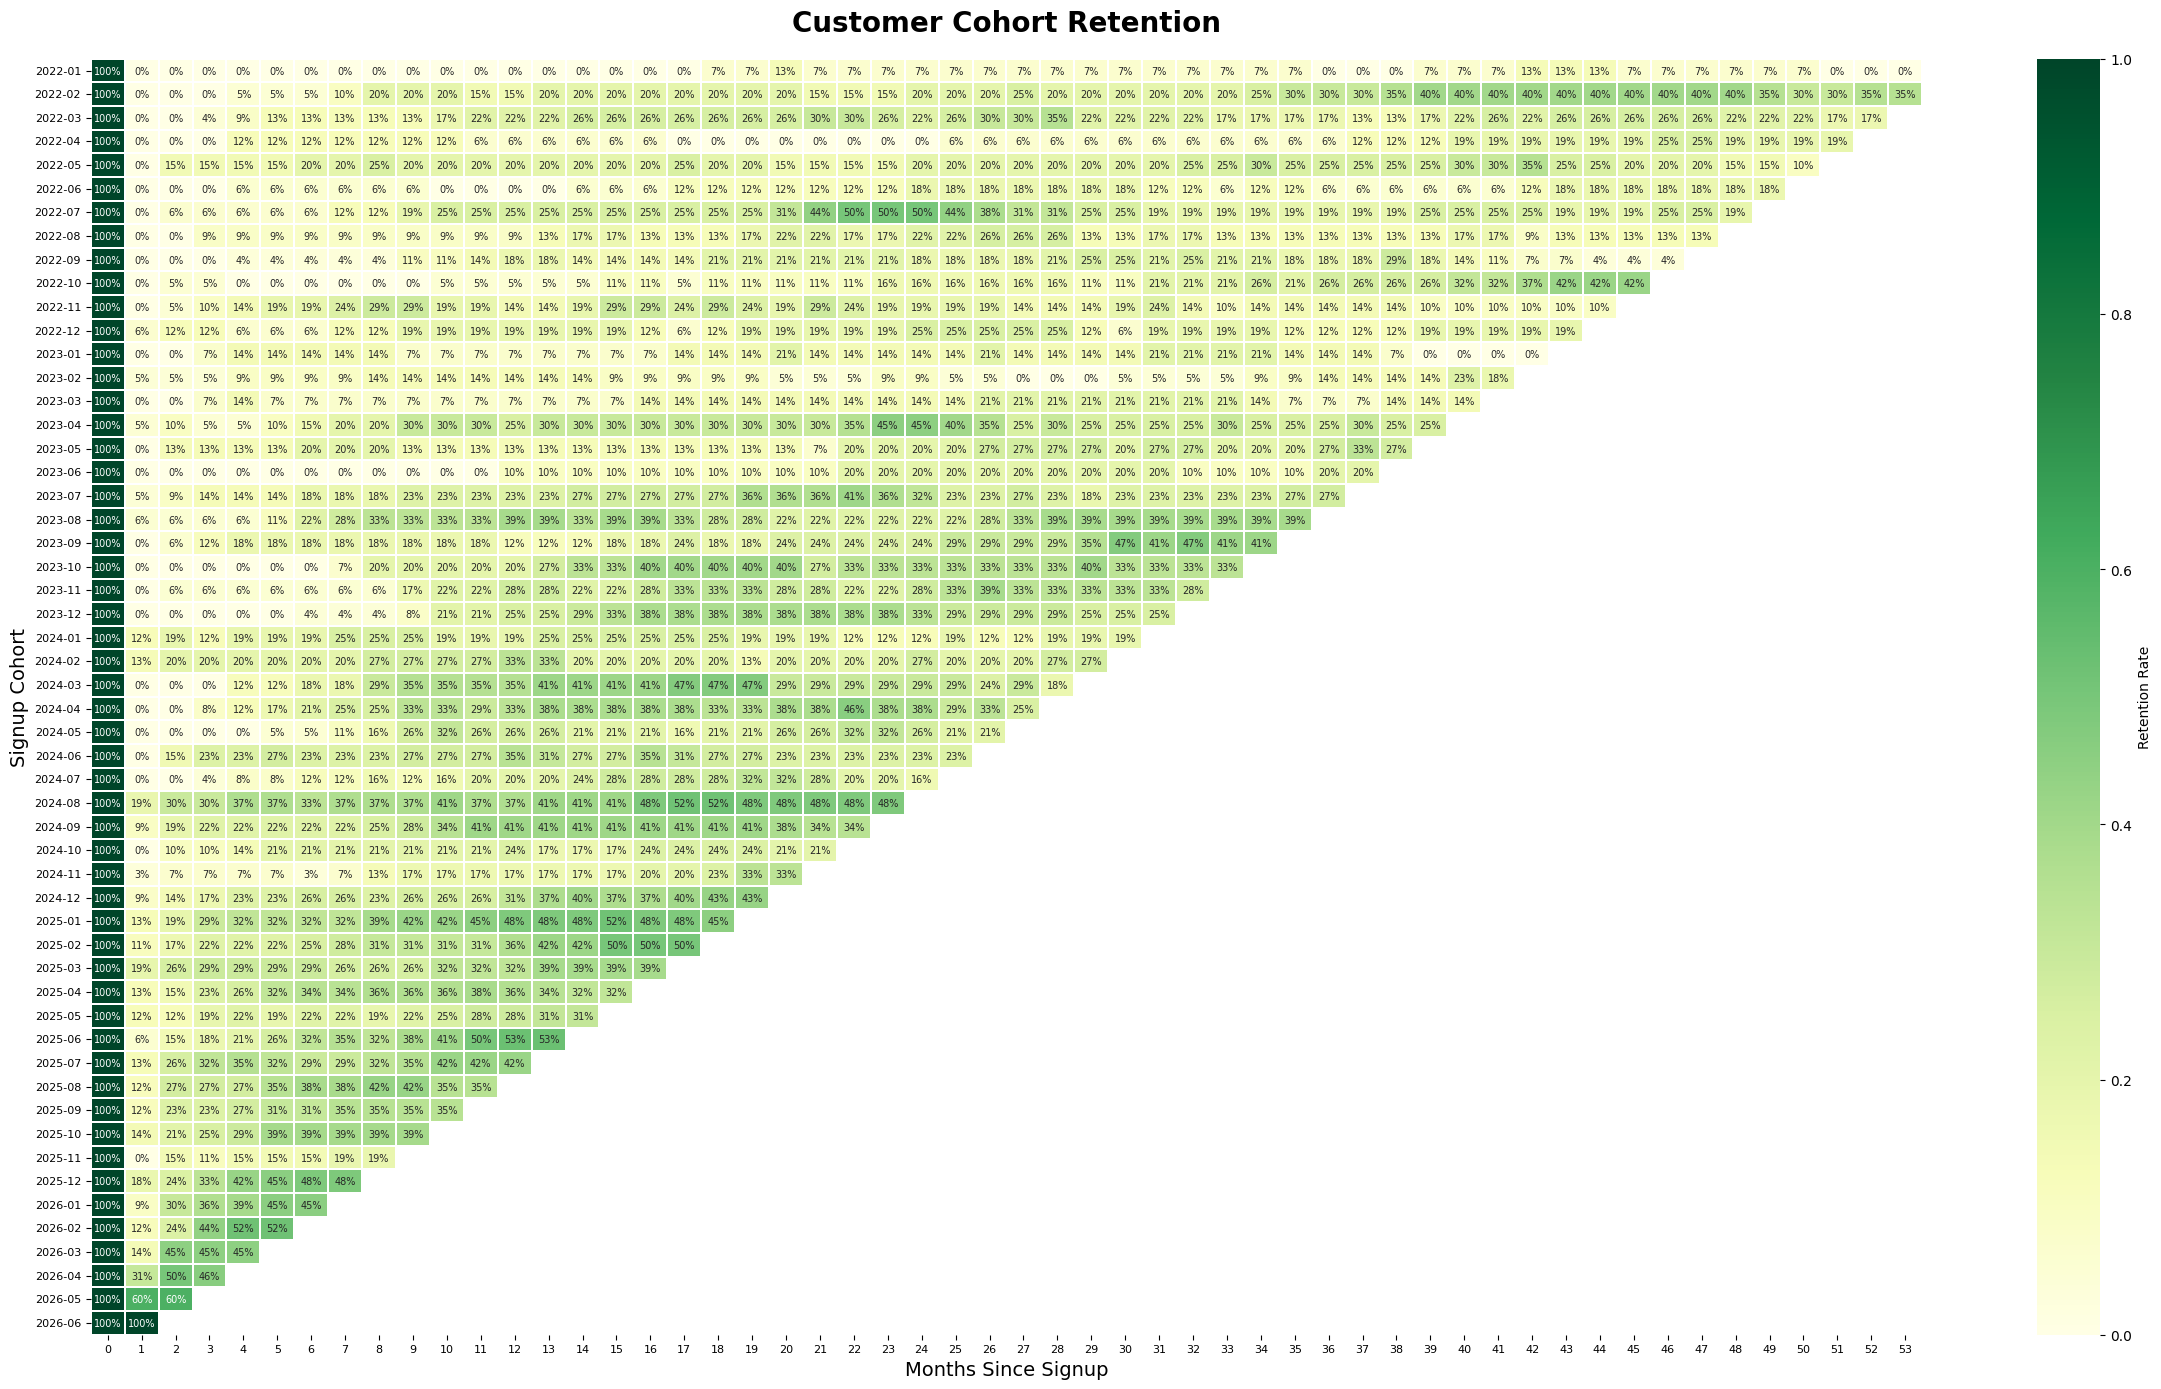

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(24, 14))

sns.heatmap(
    cohort_matrix,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".0%",
    annot_kws={"size":7},
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label":"Retention Rate"}
)

plt.title(
    "Customer Cohort Retention",
    fontsize=20,
    weight="bold",
    pad=20
)

plt.xlabel(
    "Months Since Signup",
    fontsize=14
)

plt.ylabel(
    "Signup Cohort",
    fontsize=14
)

plt.xticks(
    rotation=0,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()

plt.show()